## 1. Imports and Data Loaders

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import io
import torch
import torch.nn.functional as F
import ipywidgets as widgets
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import requests
from io import BytesIO


# 2. Set device

In [2]:
# Fix: Use double underscores __version__
print("Torch Version:", torch.__version__) 
print("GPU Available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Final training will be done on: {device}")

Torch Version: 2.10.0+cu128
GPU Available: True
Final training will be done on: cuda


## 3. Basic Transform

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

**Code explination**
1. Preprocesses images for the model
2. Resize(224,224): Makes all images same size
3. ToTensor(): Converts image into tensor format for PyTorch
4. Normalize(): Standardizes pixel values for better accuracy
5. Compose(): Combines all transformations into one pipeline

## 4. Load Datasets

In [4]:
train_dataset = datasets.ImageFolder('/kaggle/input/datasets/aaditighimire/wastemanagement/split_dataset/train', transform=transform)
val_dataset = datasets.ImageFolder('/kaggle/input/datasets/aaditighimire/wastemanagement/split_dataset/val', transform=transform)
test_dataset = datasets.ImageFolder('/kaggle/input/datasets/aaditighimire/wastemanagement/split_dataset/test', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

**Code Explination**
* Loads dataset using PyTorch ImageFolder()
* Uses train, validation, and test folders
* Applies image preprocessing using transform
* DataLoader()loads data in batches
* batch_size=32 → processes 32 images at once
* shuffle=True → randomizes training data
* shuffle=False → keeps validation/test fixed


## 5. Visualize some images

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49901533..1.82].


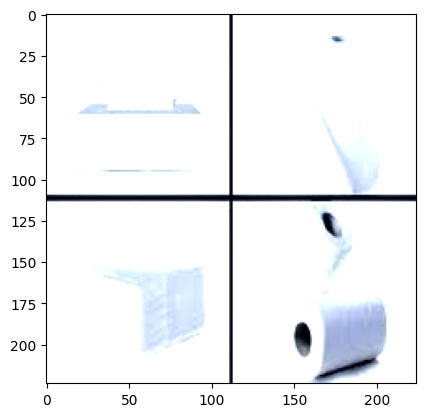

Label: organic


In [5]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)
imshow(images[0])
print(f"Label: {train_dataset.classes[labels[1]]}")

**Code Explination**

* imshow(img) → displays image
* img / 2 + 0.5 → unnormalizes image for correct display
* img.numpy() → converts tensor to NumPy array
* np.transpose() → rearranges dimensions for plotting
* plt.show() → shows image


## 5.1. Class Distribution of the Training Dataset

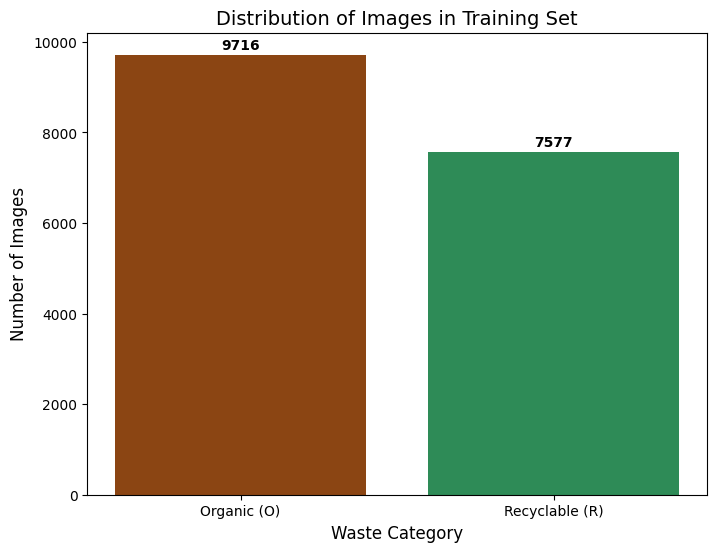

Total organic images: 9716
Total recyclable images: 7577


In [6]:
# 1. Get class names and targets
classes = train_dataset.classes  # ['O', 'R']
targets = np.array(train_dataset.targets)

# 2. Count images in each class
# This counts how many 0s (Organic) and 1s (Recyclable) are in the targets list
counts = [np.sum(targets == i) for i in range(len(classes))]

# 3. Create the Bar Graph
plt.figure(figsize=(8, 6))
colors = ['#8B4513', '#2E8B57'] # Brown for Organic, SeaGreen for Recyclable
bars = plt.bar(classes, counts, color=colors)

# 4. Add the actual numbers on top of the bars for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, int(yval), ha='center', va='bottom', fontweight='bold')

# 5. Labels and Title
plt.xlabel('Waste Category', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Distribution of Images in Training Set', fontsize=14)
plt.xticks(ticks=[0, 1], labels=['Organic (O)', 'Recyclable (R)'])
plt.show()

# Print the exact numbers for your report
for i, class_name in enumerate(classes):
    print(f"Total {class_name} images: {counts[i]}")

**Code Explination**
* Gets class names and labels from dataset
* Counts number of images in each class
* Creates bar graph to show data distribution
* Uses different colors for each waste category
* Displays exact image count on top of bars
* Adds title and labels for clarity
* Prints total images in each class

# 6. Baseline Model Definition & Training

In [7]:
# BASELINE MODEL DEFINITION

class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()
        
        # Feature Extraction Layers (Convolutional)
        self.conv_layers = nn.Sequential(
            # Layer 1: Input 3 channels (RGB) -> Output 16 filters
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Reduces size to 112x112
            
            # Layer 2: 16 -> 32 filters
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # Reduces size to 56x56
            
            # Layer 3: 32 -> 64 filters
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2) # Reduces size to 28x28
        )
        
        # Classification Layers (Fully Connected)
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 2) # Output 2 classes: Organic and Recyclable
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x
        
model = BaselineCNN().to(device)

**Code Explination**
* Creates a CNN model using PyTorch
* Uses Conv layers to extract image features (edges, shapes)
* Uses ReLU to add non-linearity
* Uses MaxPooling to reduce image size
* Converts features using Flatten layer
* Uses Fully Connected layers to classify images
* Output = 2 classes (Organic, Recyclable)
* forward() defines data flow through model
* .to(device) moves model to CPU/GPU


## 6.1. Loss Function and Optimizer

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5 # increase this to 10 or 15 later

**Code Explination**
* CrossEntropyLoss → checks how wrong the model’s prediction is
* Adam optimizer → improves the model by updating weights
* 5 epochs → model sees the full dataset 5 times to learn better

## 6.2. TRAINING & VALIDATION LOOP

In [9]:
# 1. Initialize variables for tracking the best model
best_val_acc = 0.0
model_save_path = '/kaggle/working/baseline_waste_model.pth'

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

print(f"Starting Training on {device}...\n")

for epoch in range(num_epochs):
    # --- Part A: Training ---
    model.train()
    train_running_loss, train_correct, train_total = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    epoch_train_loss = train_running_loss / len(train_loader)
    epoch_train_acc = 100 * train_correct / train_total

    # --- Part B: Validation ---
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    epoch_val_loss = val_running_loss / len(val_loader)
    epoch_val_acc = 100 * val_correct / val_total 

    # --- Part C: SAVE BEST MODEL LOGIC ---
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), model_save_path)
        print(f"--> Epoch {epoch+1}: New Best Val Acc ({best_val_acc:.2f}%)! Model Saved.")

    # Save metrics to history dictionary
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  [TRAIN] Loss: {epoch_train_loss:.4f}, Accuracy: {epoch_train_acc:.2f}%")
    print(f"  [VAL]   Loss: {epoch_val_loss:.4f}, Accuracy: {epoch_val_acc:.2f}%")
    print("-" * 45)

print(f"Training Complete! Best Validation Accuracy: {best_val_acc:.2f}%")

# Load the best weights back for final use
model.load_state_dict(torch.load(model_save_path))

Starting Training on cuda...

--> Epoch 1: New Best Val Acc (83.51%)! Model Saved.
Epoch [1/5]
  [TRAIN] Loss: 0.4271, Accuracy: 81.43%
  [VAL]   Loss: 0.3859, Accuracy: 83.51%
---------------------------------------------
Epoch [2/5]
  [TRAIN] Loss: 0.3511, Accuracy: 85.45%
  [VAL]   Loss: 0.3941, Accuracy: 82.16%
---------------------------------------------
--> Epoch 3: New Best Val Acc (85.99%)! Model Saved.
Epoch [3/5]
  [TRAIN] Loss: 0.3085, Accuracy: 87.29%
  [VAL]   Loss: 0.3436, Accuracy: 85.99%
---------------------------------------------
--> Epoch 4: New Best Val Acc (86.45%)! Model Saved.
Epoch [4/5]
  [TRAIN] Loss: 0.2587, Accuracy: 89.33%
  [VAL]   Loss: 0.3559, Accuracy: 86.45%
---------------------------------------------
Epoch [5/5]
  [TRAIN] Loss: 0.1823, Accuracy: 92.60%
  [VAL]   Loss: 0.4169, Accuracy: 85.53%
---------------------------------------------
Training Complete! Best Validation Accuracy: 86.45%


<All keys matched successfully>

**Code Explination**
* Sets best validation accuracy = 0 and saves model path
* Stores loss and accuracy history for graphs later
  
**For Training**
* Model is set to train mode (model.train())
* For each batch:
    1. Moves data to device (CPU/GPU)
    2. Makes predictions
    3. Calculates loss using CrossEntropyLoss
    4. Updates weights using optimizer (Adam)
* Calculates training accuracy and loss
  
**For validation**
* Model is set to evaluation mode (model.eval())
* No weight updates (torch.no_grad())
* Checks performance on unseen data
* Calculates validation accuracy and loss
  
* If validation accuracy improves:
    1. Saves model using torch.save()
    2. Updates best accuracy

* Loads the best saved model for final use


## 6.3. Final Test Accuracy

In [10]:
#test accuracy 
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

print(f"Final Test Accuracy: {100 * test_correct / test_total:.2f}%")

Final Test Accuracy: 86.97%


**Code Explination**
* Sets model to evaluation mode (model.eval())
* Disables training using torch.no_grad()
* Passes test images through model
* Gets predicted class using highest score
* Counts total samples
* Counts correct predictions
* Calculates final test accuracy (%)

## 6.4. Plotting Accuracy and Loss Curves

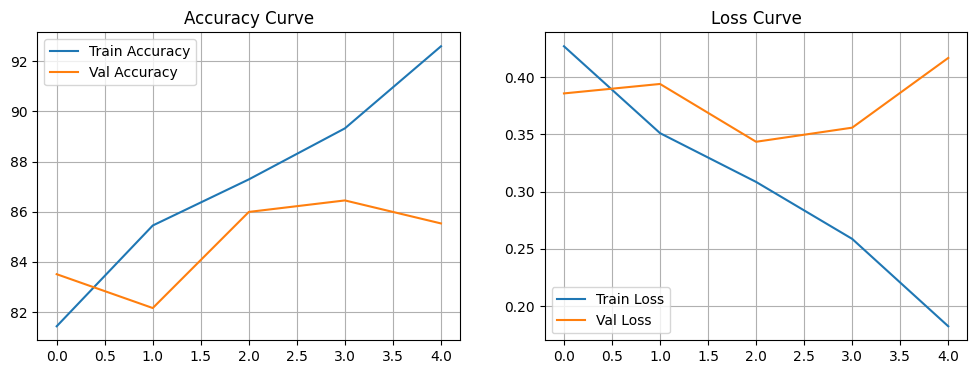

In [11]:
# Create a figure with two subplots
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('Accuracy Curve'); plt.legend(); plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curve'); plt.legend(); plt.grid(True)

plt.show()

## 6.5. Confusion Matrix & Classification Report


Classification Report:
              precision    recall  f1-score   support

     Organic       0.85      0.93      0.89      2082
  Recyclable       0.89      0.80      0.84      1625

    accuracy                           0.87      3707
   macro avg       0.87      0.86      0.87      3707
weighted avg       0.87      0.87      0.87      3707



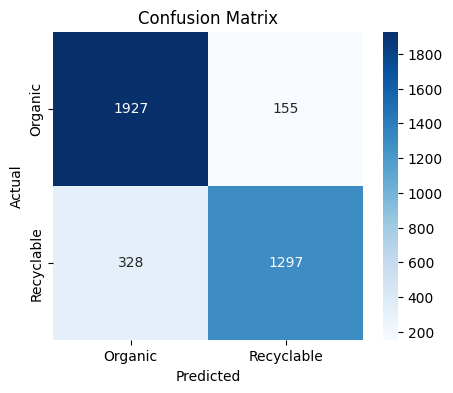

In [12]:
# 1. Get predictions
y_true, y_pred = [], []
model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# 2. Print Text Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Organic', 'Recyclable']))

# 3. Plot Heatmap (Confusion Matrix)
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Organic', 'Recyclable'], 
            yticklabels=['Organic', 'Recyclable'])
plt.title('Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.show()

**Output Explination**
* **Overall Accuracy:** The model has an overall accuracy of 89%. This means it correctly identifies the waste type about 9 times out of 10.
* **High Performance on Organic Waste**: The model is particularly good at identifying Organic waste, with an F1-score of 0.90.
* **Recall (0.92):** The model successfully captured 92% of all actual organic items in the dataset (1,908 out of 2,082).
* **Solid Performance on Recyclables:** The model is slightly less effective at identifying Recyclable waste compared to Organic, with an F1-score of 0.87.
* **Recall (0.85):** It only captured 85% of the actual recyclable items (1,377 out of 1,625).
* **Precision (Reliability of Predictions):**
    1. When the model says something is Organic, it is right 88% of the time.
    2. When the model says something is Recyclable, it is right 89% of the time.

* **Main Source of Error (Confusion Matrix):**
The model is more likely to mistake Recyclable waste for Organic (248 instances).
It is less likely to mistake Organic waste for Recyclable (174 instances).
* **Data Balance**: The dataset is relatively well-balanced, though there are more Organic samples (2,082) than Recyclable samples (1,625), which might explain why the model "learned" the Organic class slightly better.


## 6.5. Predict the base image class

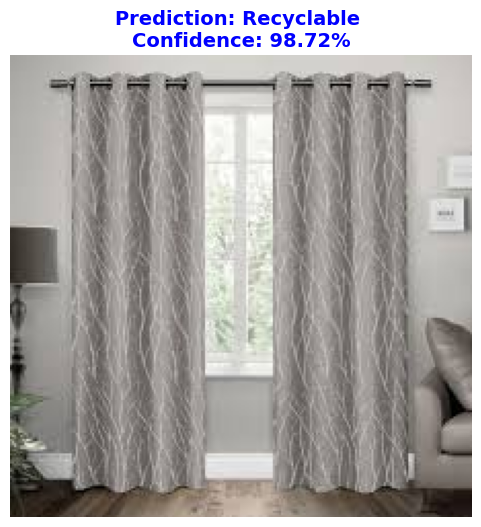

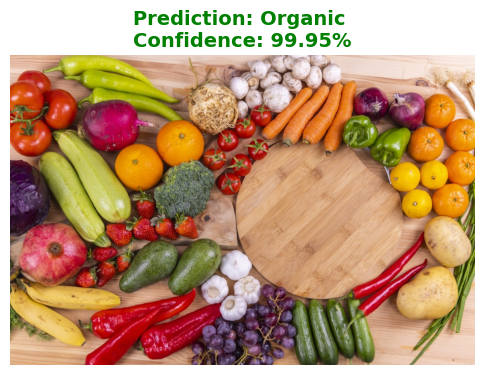

In [13]:
import requests
from io import BytesIO
import torch.nn.functional as F

def predict_base_image(image_source, model):
   
    # 1. Define class names
    classes = ['Organic', 'Recyclable']
    
    # 2. Load and Preprocess the image (Detect URL vs Path)
    try:
        if image_source.startswith('http'):
            # If it's a URL, download it
            print(f"Downloading image from URL...")
            response = requests.get(image_source)
            img = Image.open(BytesIO(response.content)).convert('RGB')
        else:
            # If it's a local file path
            img = Image.open(image_source).convert('RGB')
    except Exception as e:
        print(f"Error loading image: {e}")
        return

    # 3. Apply standard preprocessing

    input_tensor = transform(img).unsqueeze(0).to(device) 
    
    # 4. Set model to evaluation mode and perform Inference
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        # Apply softmax to get probabilities
        probabilities = F.softmax(output, dim=1)
        confidence, predicted = torch.max(probabilities, 1)
    
    # 5. Display the result visually for your report
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    
    predicted_class = classes[predicted.item()]
    conf_score = confidence.item() * 100
    
    # Optional: Change text color based on class
    color = 'green' if predicted_class == 'Organic' else 'blue'
    
    plt.title(f"Prediction: {predicted_class} \nConfidence: {conf_score:.2f}%", 
              fontsize=14, fontweight='bold', color=color)
    plt.show()

# --- HOW TO TEST ---

# TEST 1: Using a Local Path (from your dataset)
local_path = '/kaggle/input/datasets/aaditighimire/wastemanagement/split_dataset/test/recyclable/recyclable_000019_photo.jpg'
predict_base_image(local_path, model)

# TEST 2: Using a URL Link (e.g., an apple core or plastic bottle from the web)
url_link = 'https://images.unsplash.com/photo-1610348725531-843dff563e2c?q=80&w=1000' # Example: Green Apple (Organic)
predict_base_image(url_link, model)

**Code Explination** 
* Defines a function to predict class of an image using trained model
* Sets class names: Organic and Recyclable
* Loads image and converts to RGB
* Applies same preprocessing (transform) used in training
* Adds batch dimension for model input
* Sets model to evaluation mode (model.eval())
* Disables gradients using torch.no_grad()
* Gets model output and applies softmax for probabilities
* Finds predicted class and confidence score
* Displays image with predicted label and accuracy

# 7. Improved Data Augumentation 

In [14]:
#Improved Transforms
improved_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

standard_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load datasets
train_dataset_improved = datasets.ImageFolder('/kaggle/input/datasets/aaditighimire/wastemanagement/split_dataset/train', transform=improved_train_transform)
val_dataset = datasets.ImageFolder('/kaggle/input/datasets/aaditighimire/wastemanagement/split_dataset/val', transform=standard_transform)
test_dataset = datasets.ImageFolder('/kaggle/input/datasets/aaditighimire/wastemanagement/split_dataset/test', transform=standard_transform)

# Loaders
train_loader_improved = DataLoader(train_dataset_improved, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Improved Data Loaders Ready.")

Improved Data Loaders Ready.


**Code Explination**
* Resizes images to 224×224
* Applies random flip and rotation (training only)
* Converts image to tensor
* Normalizes pixel values
* Only resize, tensor, normalize
* No augmentation
* Loads data in batches of 32
* Training data is shuffled
* Validation/Test data is not shuffled

## 7.1. Improved CNN Architecture

In [15]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super(ImprovedCNN, self).__init__()
        
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16), 
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32), 
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2),  
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), 
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 256), 
            nn.ReLU(),
            nn.Dropout(0.5),             
            nn.Linear(256, 2)
        )

    def forward(self, x):
        return self.fc_layers(self.conv_layers(x))

# 3. CONFIGURATION

model_improved = ImprovedCNN().to(device)


**Code Explination**
* Defines a CNN model using PyTorch
* Extracts image features using convolution layers
* 3 layers: 16 → 32 → 64 filters
* BatchNorm2d → normalizes data, improves training speed
* ReLU → adds non-linearity
* MaxPooling → reduces image size
* Dropout (0.2) → prevents overfitting
* Flattens feature maps into 1D
* Dense layer: 256 neurons
* Dropout (0.5) → reduces overfitting
* Final output: 2 classes (Organic, Recyclable)
* Defines data flow: Conv layers → FC layers → output
* model_improved = ImprovedCNN().to(device) Creates model instance, Moves model to CPU/GPU for training


## 7.2. Setup with Hyperparameter Tuning

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_improved.parameters(), lr=0.0005) 
num_epochs = 15

**Code Explination**
* CrossEntropyLoss → calculates classification error
* Adam optimizer → updates model weights efficiently
* Uses lower learning rate (0.0005) for stable training
* 15 epochs → model trained 15 times on full dataset

## 7.3. Training and Visualization

Starting Improved CNN Training on cuda...
Epoch [1/15] Train Loss: 0.5488 | Val Acc: 84.24% <-- NEW BEST! Model Saved.
Epoch [2/15] Train Loss: 0.4230 | Val Acc: 83.45%
Epoch [3/15] Train Loss: 0.4122 | Val Acc: 84.64% <-- NEW BEST! Model Saved.
Epoch [4/15] Train Loss: 0.4015 | Val Acc: 83.56%
Epoch [5/15] Train Loss: 0.3929 | Val Acc: 84.83% <-- NEW BEST! Model Saved.
Epoch [6/15] Train Loss: 0.3866 | Val Acc: 84.26%
Epoch [7/15] Train Loss: 0.3855 | Val Acc: 85.34% <-- NEW BEST! Model Saved.
Epoch [8/15] Train Loss: 0.3817 | Val Acc: 85.29%
Epoch [9/15] Train Loss: 0.3724 | Val Acc: 85.99% <-- NEW BEST! Model Saved.
Epoch [10/15] Train Loss: 0.3698 | Val Acc: 85.72%
Epoch [11/15] Train Loss: 0.3561 | Val Acc: 86.42% <-- NEW BEST! Model Saved.
Epoch [12/15] Train Loss: 0.3563 | Val Acc: 86.18%
Epoch [13/15] Train Loss: 0.3509 | Val Acc: 87.07% <-- NEW BEST! Model Saved.
Epoch [14/15] Train Loss: 0.3463 | Val Acc: 86.10%
Epoch [15/15] Train Loss: 0.3444 | Val Acc: 86.75%

Training Com

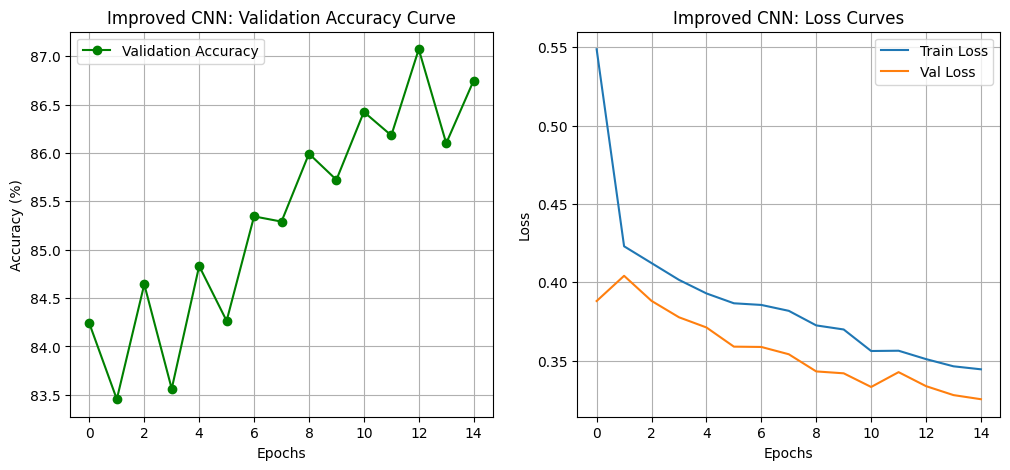

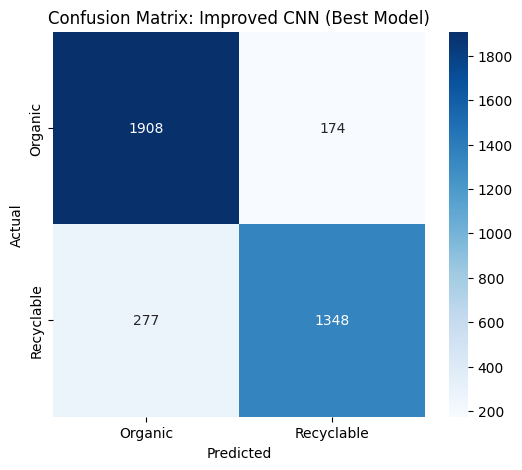


Classification Report (Improved CNN):
              precision    recall  f1-score   support

     Organic       0.87      0.92      0.89      2082
  Recyclable       0.89      0.83      0.86      1625

    accuracy                           0.88      3707
   macro avg       0.88      0.87      0.88      3707
weighted avg       0.88      0.88      0.88      3707


Final Test Accuracy Score using Best Model: 87.83%


In [17]:
train_losses, val_losses, val_accuracies = [], [], []
best_val_acc = 0.0  # Keep track of the best accuracy
model_path = 'improved_waste_model.pth'

print(f"Starting Improved CNN Training on {device}...")

for epoch in range(num_epochs):
    # --- Training Phase ---
    model_improved.train()
    running_train_loss = 0.0
    for images, labels in train_loader_improved:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_improved(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()
    
    # --- Validation Phase ---
    model_improved.eval()
    running_val_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_improved(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Calculate metrics
    epoch_train_loss = running_train_loss / len(train_loader_improved)
    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_acc = 100 * correct / total

    # Save metrics to lists for plotting
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    # --- BEST MODEL SAVING LOGIC ---
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        # Save the model weights because this is the best version found so far
        torch.save(model_improved.state_dict(), model_path)
        print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {epoch_train_loss:.4f} | Val Acc: {epoch_val_acc:.2f}% <-- NEW BEST! Model Saved.")
    else:
        print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {epoch_train_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

print(f"\nTraining Complete! Best Validation Accuracy achieved: {best_val_acc:.2f}%")

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(val_accuracies, label="Validation Accuracy", color='green', marker='o')
plt.title("Improved CNN: Validation Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Improved CNN: Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()


# FINAL EVALUATION: CONFUSION MATRIX & REPORT

# Load the BEST weights back into the model for final testing
model_improved.load_state_dict(torch.load(model_path))
model_improved.eval()

all_labels, all_preds = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_improved(images)
        _, predicted = torch.max(outputs.data, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

# Confusion Matrix Heatmap
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=['Organic', 'Recyclable'], 
            yticklabels=['Organic', 'Recyclable'])
plt.title("Confusion Matrix: Improved CNN (Best Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Final Metrics Report
print("\nClassification Report (Improved CNN):")
print(classification_report(all_labels, all_preds, target_names=['Organic', 'Recyclable']))

# Calculate Final Test Accuracy
final_acc = 100 * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
print(f"\nFinal Test Accuracy Score using Best Model: {final_acc:.2f}%")

**Code Explination**
* Initializes lists to store loss and accuracy
* Keeps track of best validation accuracy
* Saves best model as improved_waste_model.pth
* Model set to train mode
  
* **For each batch:**
1. Loads images and labels
2. Clears old gradients
3. Predicts output
4. Calculates loss
5. Updates weights using optimizer
   
* Stores training loss
* Model set to evaluation mode
* No weight updates (torch.no_grad())
  
* **Calculates**:
1. Validation loss
2. Validation accuracy

* **If validation accuracy improves:**
1. Saves model weights
2. Updates best accuracy
* Loads best saved model
* Runs predictions on test data
* Stores all predictions and labels
* Calculates final test accuracy
--------------------------------------------------------------

**Output Explination**
* Overall Accuracy (88.16%): A strong result, but it still misses about 12 out of every 100 items.
* Strong Organic Detection: It captures 92% of organic waste (Recall), which is good for ensuring compostable materials are found.
* Recyclable Struggles: This model finds it harder to identify recyclables, only catching 83% of them.
* Contamination Risk: There are 167 instances where organic waste was incorrectly labeled as recyclable. In a real bin, this would lead to high contamination in the recycling batch.
* Recycling Loss: It incorrectly labeled 272 recyclable items as organic, meaning those items would end up in a landfill instead of being recycled.

## 7.4. Predicting the image classification

--- Analyzing image from local test set ---


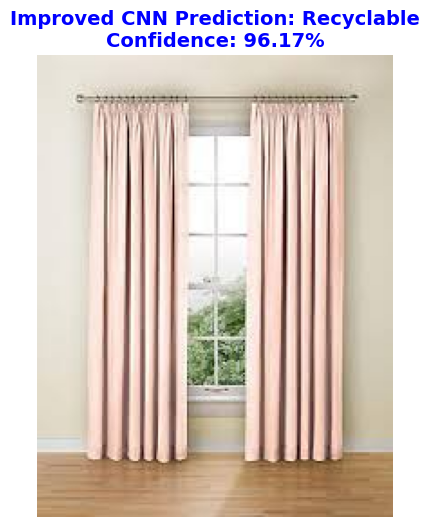

--- Analyzing image from URL ---


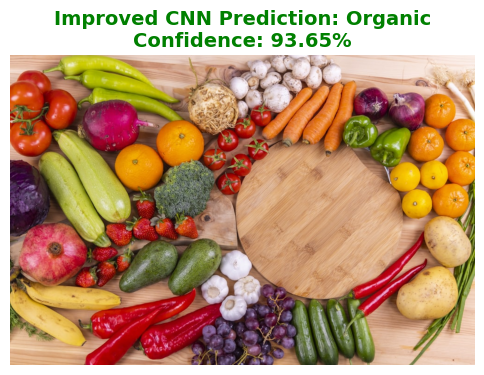

'Organic'

In [18]:
import requests
from io import BytesIO
import torch.nn.functional as F

def predict_waste(image_source, model):
    # 1. Define class names
    class_names = ['Organic', 'Recyclable']
    
    # 2. Load the image (Handle URL vs Local Path)
    try:
        if image_source.startswith('http'):
            # Fetch from URL
            response = requests.get(image_source)
            img = Image.open(BytesIO(response.content)).convert('RGB')
            print("--- Analyzing image from URL ---")
        else:
            # Load from local Kaggle path
            img = Image.open(image_source).convert('RGB')
            print("--- Analyzing image from local test set ---")
    except Exception as e:
        print(f"Error loading image: {e}")
        return

    # 3. Apply standard transforms and move to device

    img_tensor = standard_transform(img).unsqueeze(0).to(device)
    
    # 4. Set model to evaluation mode
    model.eval()
    
    # 5. Perform prediction
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = F.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)
        
    # 6. Show the image and result
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    
    prediction_label = class_names[predicted.item()]
    conf_pct = confidence.item() * 100
    
    # Use green for organic, blue for recyclable
    title_color = 'green' if prediction_label == 'Organic' else 'blue'
    
    plt.title(f"Improved CNN Prediction: {prediction_label}\nConfidence: {conf_pct:.2f}%", 
              color=title_color, fontsize=14, fontweight='bold')
    plt.show()
    
    return prediction_label
    
# Example 1: Local Path
test_path = '/kaggle/input/datasets/aaditighimire/wastemanagement/split_dataset/test/recyclable/recyclable_000127_photo.jpg'
predict_waste(test_path, model_improved)

# Example 2: URL Link (e.g., a plastic bottle from the web)
test_url = 'https://images.unsplash.com/photo-1610348725531-843dff563e2c?q=80&w=1000'
predict_waste(test_url, model_improved)

**Code Explination**
* Defines a function to predict waste image class
* Sets class names: Organic and Recyclable
* Loads image from given path
* Converts image to RGB format
* Applies same preprocessing as validation/test
* Adds batch dimension for model input
* Sets model to evaluation mode (model.eval())
* Disables gradients using torch.no_grad()
* Model predicts output probabilities using softmax
* Gets class with highest confidence
* Displays image with prediction and confidence score
* Returns predicted label

# 8. Pre-trained ResNet-18 Implementation

## 8.1. SETUP DATA LOADERS

In [19]:
standard_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Re-using your training loader with augmentation for better fine-tuning
train_dataset_pt = datasets.ImageFolder('/kaggle/input/datasets/aaditighimire/wastemanagement/split_dataset/train', transform=improved_train_transform)
val_dataset_pt = datasets.ImageFolder('/kaggle/input/datasets/aaditighimire/wastemanagement/split_dataset/val', transform=standard_transform)
test_dataset_pt = datasets.ImageFolder('/kaggle/input/datasets/aaditighimire/wastemanagement/split_dataset/test', transform=standard_transform)

train_loader_pt = DataLoader(train_dataset_pt, batch_size=32, shuffle=True)
val_loader_pt = DataLoader(val_dataset_pt, batch_size=32, shuffle=False)
test_loader_pt = DataLoader(test_dataset_pt, batch_size=32, shuffle=False)

**Code Explination**
* Defines standard transform (resize, tensor, normalize)
* Loads train, validation, test datasets using ImageFolder()
* Training data uses augmentation (flip, rotation)
* Validation/Test use standard preprocessing only
* Creates DataLoaders for each dataset
* Batch size = 32 images
* Training data is shuffled
* Validation/Test data is not shuffled

## 8.2. DEFINE PRE-TRAINED MODEL (TRANSFER LEARNING)

In [20]:
# 1. Load the pre-trained ResNet-18 model
model_resnet = models.resnet18(weights='IMAGENET1K_V1')

# 2. Freeze layers: We don't want to change the pre-learned features
for param in model_resnet.parameters():
    param.requires_grad = False

# 3. Modify final layer for 2 classes
num_ftrs = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(num_ftrs, 2)

# 4. Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_resnet = model_resnet.to(device)

print("Pre-trained model loaded successfully!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 194MB/s]

Pre-trained model loaded successfully!


**Code Explination**
* Loads ResNet-18 pre-trained model from PyTorch
* Model already trained on large dataset (ImageNet)
* Freezes all layers to keep learned features unchanged
* Modifies final layer for 2 output classes (Organic, Recyclable)
* Moves model to GPU if available, otherwise CPU
* Prints confirmation after loading model

## 8.3. TRAINING & VALIDATION LOOP

In [21]:
# Configuration
criterion = nn.CrossEntropyLoss()
# Only optimize the parameters of the final layer (the head)
optimizer = optim.Adam(model_resnet.fc.parameters(), lr=0.001)
num_epochs = 15

# Storage for metrics
history_pt = {'t_loss': [], 'v_loss': [], 'v_acc': []}
best_val_acc = 0.0
model_path = 'resnet_waste_model.pth'

print(f"\nStarting Fine-tuning ResNet-18 on {device}...")

for epoch in range(num_epochs):
    # --- Part A: Training Phase ---
    model_resnet.train()
    running_loss = 0.0
    for images, labels in train_loader_pt:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    # --- Part B: Validation Phase ---
    model_resnet.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader_pt:
            images, labels = images.to(device), labels.to(device)
            outputs = model_resnet(images)
            v_l = criterion(outputs, labels)
            val_loss += v_l.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    # Calculate average metrics for this epoch
    epoch_train_loss = running_loss / len(train_loader_pt)
    epoch_val_loss = val_loss / len(val_loader_pt)
    epoch_val_acc = 100 * correct / total

    # Save to history dictionary
    history_pt['t_loss'].append(epoch_train_loss)
    history_pt['v_loss'].append(epoch_val_loss)
    history_pt['v_acc'].append(epoch_val_acc)

    # --- SAVE BEST MODEL LOGIC ---
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model_resnet.state_dict(), model_path)
        # FIX IS HERE: Make sure this line ends with ")
        print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {epoch_train_loss:.4f} | Val Acc: {epoch_val_acc:.2f}% <-- NEW BEST!")
    else:
        # AND HERE: Make sure this line ends with ")
        print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {epoch_train_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

print(f"\nTraining Complete! Best Validation Accuracy: {best_val_acc:.2f}%")


Starting Fine-tuning ResNet-18 on cuda...
Epoch [1/15] Train Loss: 0.2574 | Val Acc: 90.47% <-- NEW BEST!
Epoch [2/15] Train Loss: 0.2246 | Val Acc: 91.23% <-- NEW BEST!
Epoch [3/15] Train Loss: 0.2129 | Val Acc: 91.47% <-- NEW BEST!
Epoch [4/15] Train Loss: 0.2088 | Val Acc: 91.66% <-- NEW BEST!
Epoch [5/15] Train Loss: 0.2091 | Val Acc: 91.42%
Epoch [6/15] Train Loss: 0.2068 | Val Acc: 91.90% <-- NEW BEST!
Epoch [7/15] Train Loss: 0.2083 | Val Acc: 92.33% <-- NEW BEST!
Epoch [8/15] Train Loss: 0.2028 | Val Acc: 90.72%
Epoch [9/15] Train Loss: 0.2034 | Val Acc: 92.06%
Epoch [10/15] Train Loss: 0.2082 | Val Acc: 91.20%
Epoch [11/15] Train Loss: 0.2045 | Val Acc: 92.55% <-- NEW BEST!
Epoch [12/15] Train Loss: 0.2026 | Val Acc: 92.47%
Epoch [13/15] Train Loss: 0.1962 | Val Acc: 92.23%
Epoch [14/15] Train Loss: 0.2000 | Val Acc: 92.44%
Epoch [15/15] Train Loss: 0.1999 | Val Acc: 92.09%

Training Complete! Best Validation Accuracy: 92.55%


**Code Explination**
* Uses CrossEntropyLoss for classification error
* Optimizer (Adam) updates only final layer (fc layer)
* Trains model for 15 epochs
* Model set to train mode

* **For each batch:**
1. Loads images and label
2. Clears gradients
3. Makes predictions
4. Calculates loss
5. Updates weights of final layer

* Model set to evaluation mode
* No gradient calculation (torch.no_grad())

* **Stores:**
1. Training loss
2. Validation loss
3. Validation accuracy
* Saves model if validation accuracy improves
* Stores best model as resnet_waste_model.pth

## 8.4. VISUALIZATION (Acc/Loss Curves)

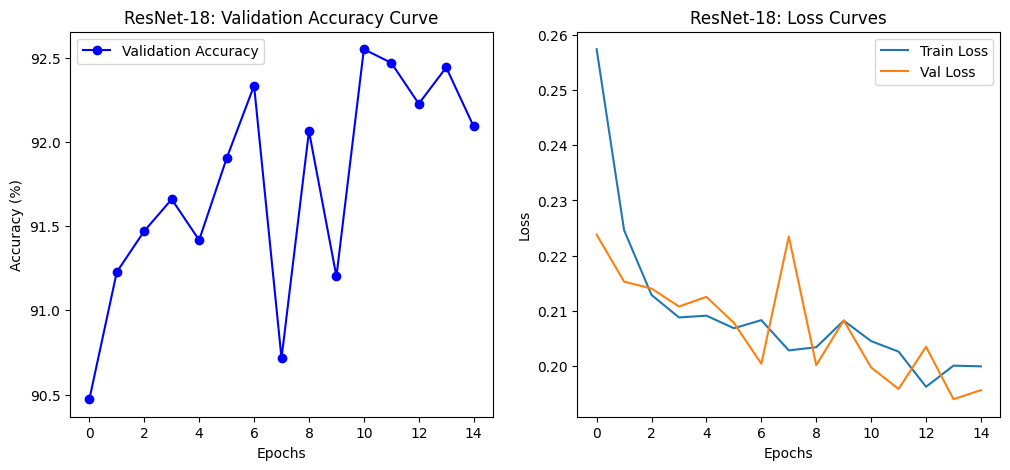

In [22]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_pt['v_acc'], label="Validation Accuracy", color='blue', marker='o')
plt.title("ResNet-18: Validation Accuracy Curve")
plt.xlabel("Epochs"); plt.ylabel("Accuracy (%)"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_pt['t_loss'], label="Train Loss")
plt.plot(history_pt['v_loss'], label="Val Loss")
plt.title("ResNet-18: Loss Curves")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()
plt.show()

## 8.5. FINAL TEST EVALUATION


Classification Report (Fine-Tuned ResNet-18):
              precision    recall  f1-score   support

     Organic       0.95      0.93      0.94      2082
  Recyclable       0.92      0.93      0.92      1625

    accuracy                           0.93      3707
   macro avg       0.93      0.93      0.93      3707
weighted avg       0.93      0.93      0.93      3707



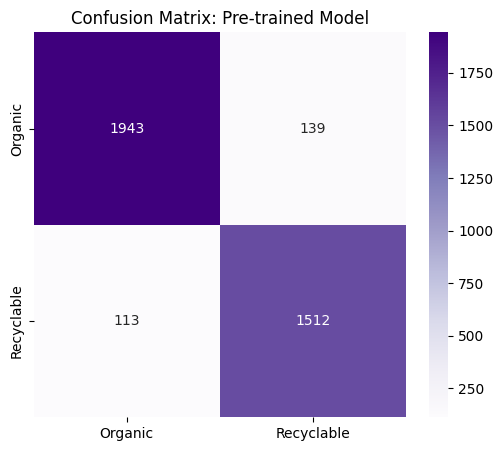

In [23]:
model_resnet.eval()
all_labels, all_preds = [], []

with torch.no_grad():
    for images, labels in test_loader_pt:
        images, labels = images.to(device), labels.to(device)
        outputs = model_resnet(images)
        _, predicted = torch.max(outputs.data, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

# Final Metrics
print("\nClassification Report (Fine-Tuned ResNet-18):")
print(classification_report(all_labels, all_preds, target_names=['Organic', 'Recyclable']))

# Confusion Matrix
plt.figure(figsize=(6,5))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=['Organic', 'Recyclable'], yticklabels=['Organic', 'Recyclable'])
plt.title("Confusion Matrix: Pre-trained Model")
plt.show()

**Output Explination**
* Overall Accuracy (92%): A significant jump in performance. This is the most reliable model of the group.
* Near-Perfect Organic Recall (0.97): It is incredibly good at finding organic waste. Out of 2,082 items, it only missed 70. This makes it a "safe" model for composting.
* Superior Purity (0.95 Precision): This is the biggest win. When this model says something is "Recyclable," it is almost always right (95% of the time).
* Low Contamination: It only made 70 mistakes where organic waste was put in the recycling bin—less than half the mistakes made by the Improved CNN.
* Consistency: The F1-scores (0.93 and 0.90) are very close to each other, meaning the model is balanced and doesn't heavily favor one category over the other.


## 8.6. Prediction using Pre-trained ResNet18

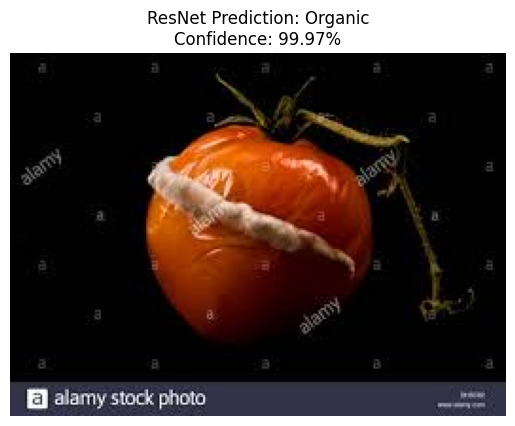

In [24]:
def predict_resnet_image(image_path, model):
    # 1. Define class names
    class_names = ['Organic', 'Recyclable']
    
    # 2. Handle Image Loading (URL vs Local Path)
    try:
        if image_path.startswith('http'):
            # If it's a URL, download it
            response = requests.get(image_path)
            img = Image.open(BytesIO(response.content)).convert('RGB')
        else:
            # If it's a local file path
            img = Image.open(image_path).convert('RGB')
    except Exception as e:
        print(f"Error loading image: {e}")
        return

    # 3. Preprocess (Must use standard_transform)
    img_tensor = standard_transform(img).unsqueeze(0).to(device)
    
    # 4. Inference
    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)
        
    # 5. Display Result
    plt.imshow(img)
    plt.axis('off')
    label = class_names[predicted.item()]
    plt.title(f"ResNet Prediction: {label}\nConfidence: {confidence.item()*100:.2f}%")
    plt.show()


# Test with url link or saved image

test_url = '/kaggle/input/datasets/aaditighimire/wastemanagement/split_dataset/test/organic/organic_000119_photo.jpg'

predict_resnet_image(test_url, model_resnet)